<div align="center">
  <img src="./img/logo.png" />
  <h1><b>1. GeoHawk: Data exploration</b></h1>
  <p></p>
</div>

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/coordinates.csv')

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25229 entries, 0 to 25228
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   25229 non-null  float64
 1   longitude  25229 non-null  float64
dtypes: float64(2)
memory usage: 394.3 KB
None


,latitude,longitude
0,20.824885,-98.499517
1,-3.451752,-54.563937
2,-23.496464,-47.460542
3,-16.548678,-72.852778
4,-35.010870,140.064397


## **1.1 Image location distribution**
The variance in the data locations is important because it shows how well different regions of the world are represented in the dataset. If there is a lot of variance, it means the images come from a wide range of places, which will help the model learn to predict locations from diverse environments. It will also be able to differentiate different areas based on their environmental features.

However, not all areas of the world are covered by Google Street View. Some regions, especially rural or remote areas, may not have any Street View images available. This is due to various factors, like limited infrastructure, privacy concerns, or local regulations. As a result, the dataset will have gaps with certain regions underrepresented or missing entirely. (As seen in figure 1).


![Google streetview coverage](./img/google-street-coverage.png)
> Figure 1 - Google streetview coverage

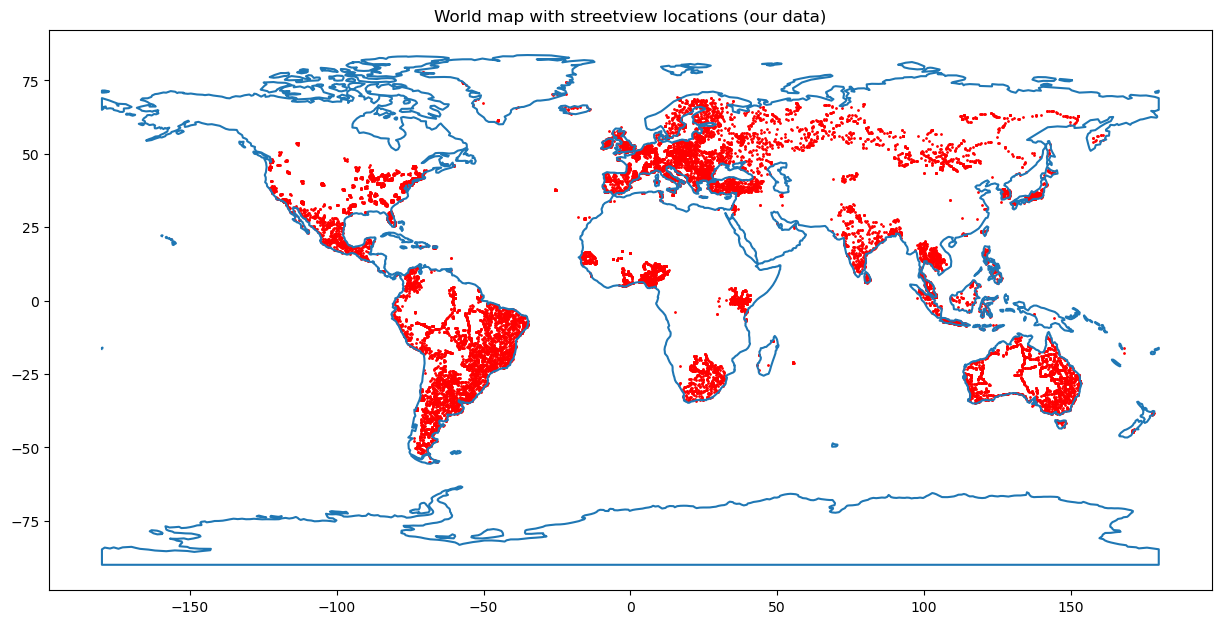

In [41]:
import geopandas as gpd
import geodatasets as gds

# create a GeoDataFrame from the DataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))

# Load a world map
world = gpd.read_file(gds.get_path('naturalearth.land'))

# Plot the data points on top of the world map
fig, ax = plt.subplots(figsize=(15, 15))
world.boundary.plot(ax=ax)
gdf.plot(ax=ax, color='red', markersize=1)
plt.title('World map with streetview locations (our data)')
plt.show()

> Plot 1 - Image data distribution (some lesser represented areas expected with ~25000 samples)

## **1.2 Image size**
Lets verify that all images have the correct dimensions. Each image should be 640 pixels in width and height (square). Having same sized images helps with consistency of the dataset.

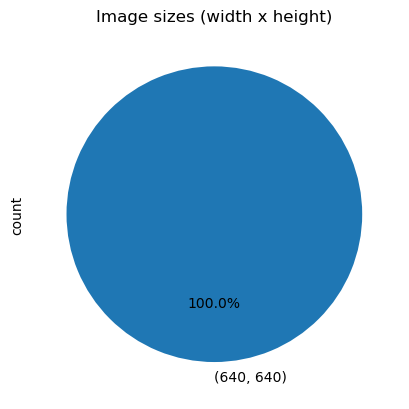

In [42]:
# Load images and check their size (image filename is {index}.png)
from PIL import Image
import os

def check_image_size(image_path):
    with Image.open(image_path) as img:
        return img.size


df['image_path'] = df.index.map(lambda x: f'data/img/{x}.png')
df['image_size'] = df['image_path'].map(check_image_size)

# plot the image sizes in a pie chart
df['image_size'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Image sizes (width x height)')
plt.show()

> All images are of size 640x640

## **1.3 Latitude and Longitude distribution**

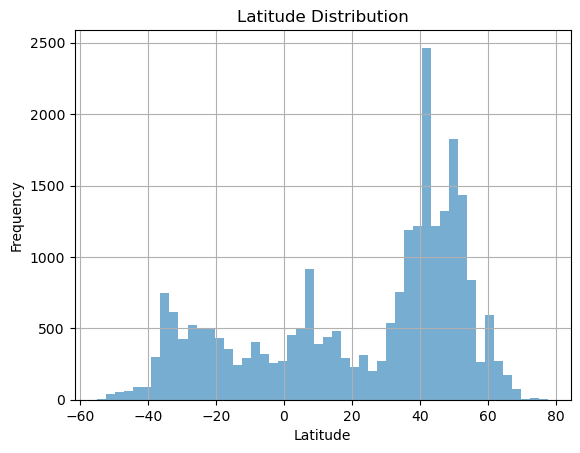

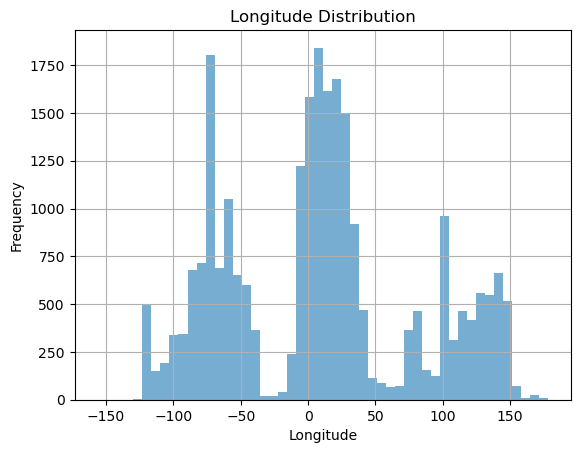

In [43]:
# Latitude histogram
df['latitude'].hist(bins=50, alpha=0.6)
plt.title('Latitude Distribution')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.show()

# Longitude histogram
df['longitude'].hist(bins=50, alpha=0.6)
plt.title('Longitude Distribution')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.show()

## **1.4 Image variance**

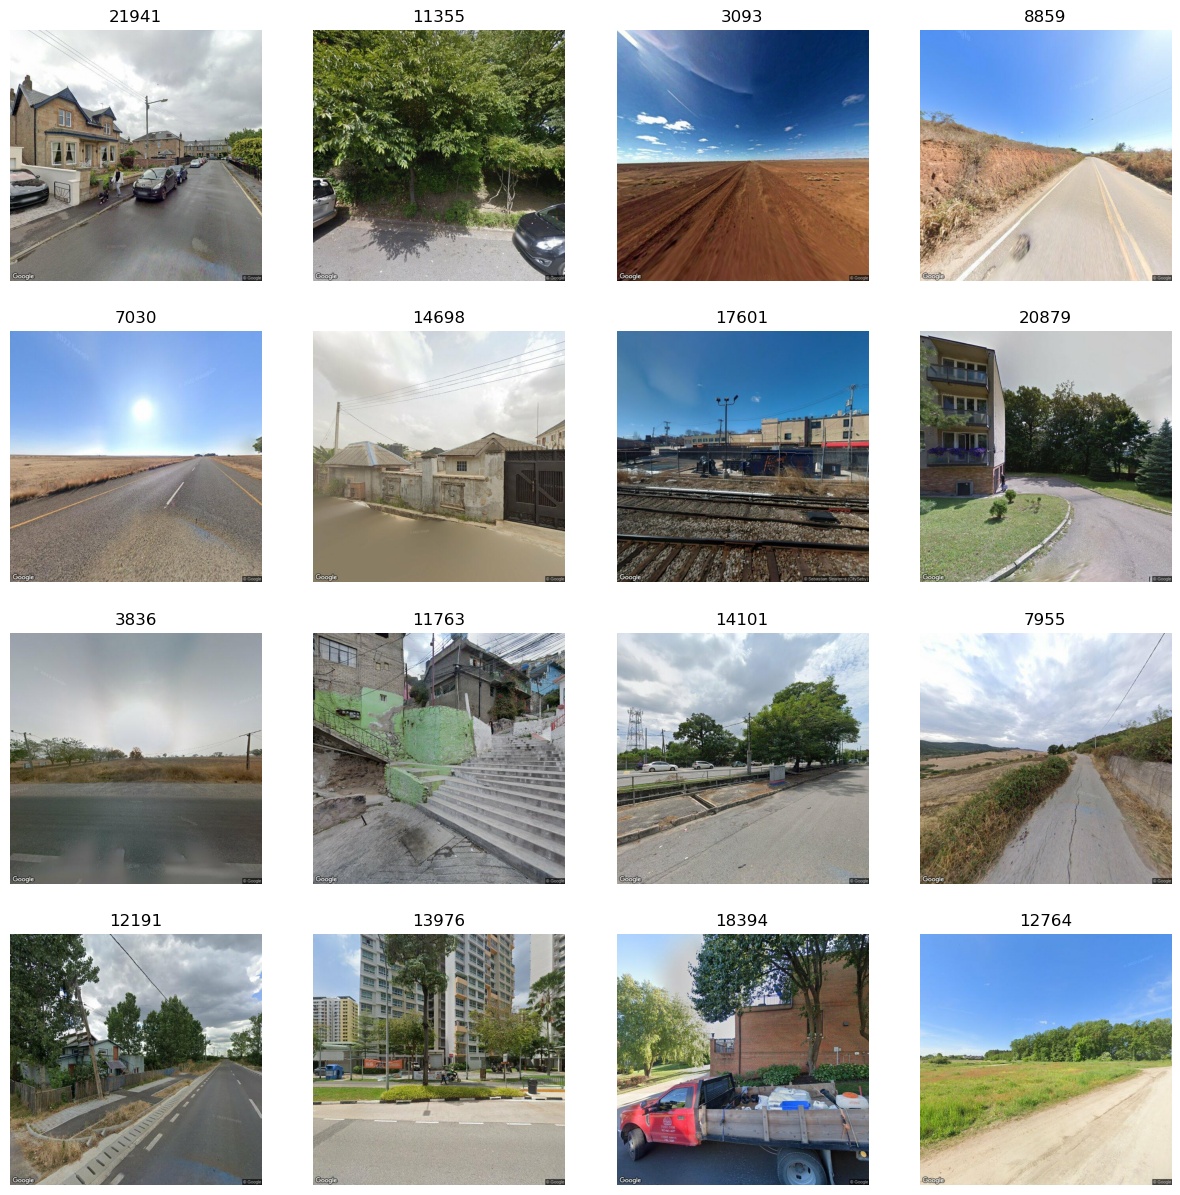

In [45]:
# Plot random images from the /data/img folder
import random
import geopy as gp

fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    idx = random.choice(df.index)
    img = Image.open(df.loc[idx, 'image_path'])
    ax.imshow(img)
    ax.set_title(idx)
    ax.axis('off')